<a href="https://colab.research.google.com/github/shanziee/ihsan/blob/main/Pra_Penugasan_State_Space.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install osmnx


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.5/101.5 kB 1.7 MB/s eta 0:00:00


In [19]:
import osmnx as ox
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from shapely.geometry import Point
kabupaten = ox.geocode_to_gdf("Kabupaten Banyumas, Jawa Tengah, Indonesia")
kecamatan_banyumas = ox.features_from_place(
"Kabupaten Banyumas, Jawa Tengah, Indonesia",
tags={"amenity": "school"}
)
kabupaten.head()
kabupaten.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

<Axes: >

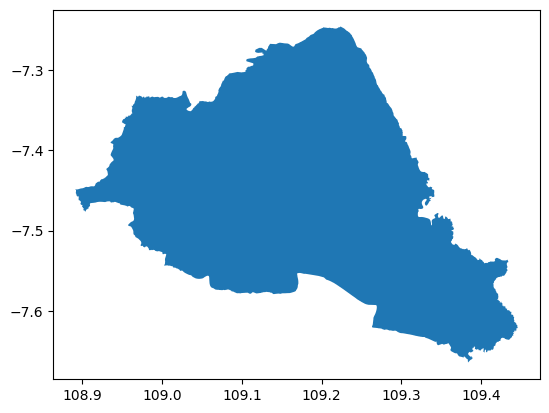

In [20]:
kabupaten.plot()

Memulai proses geocoding untuk 27 kecamatan...
⚠️ Poligon tidak ditemukan untuk Ajibarang, mencoba mencari titik koordinat...
    -> Berhasil ditambahkan sebagai titik.
⚠️ Poligon tidak ditemukan untuk Banyumas, mencoba mencari titik koordinat...
    -> Berhasil ditambahkan sebagai titik.
✅ Berhasil mendapatkan poligon untuk: Baturraden
⚠️ Poligon tidak ditemukan untuk Cilongok, mencoba mencari titik koordinat...
    -> Berhasil ditambahkan sebagai titik.
⚠️ Poligon tidak ditemukan untuk Gumelar, mencoba mencari titik koordinat...
    -> Berhasil ditambahkan sebagai titik.
⚠️ Poligon tidak ditemukan untuk Jatilawang, mencoba mencari titik koordinat...
    -> Berhasil ditambahkan sebagai titik.
⚠️ Poligon tidak ditemukan untuk Kalibagor, mencoba mencari titik koordinat...
    -> Berhasil ditambahkan sebagai titik.
⚠️ Poligon tidak ditemukan untuk Karanglewas, mencoba mencari titik koordinat...
    -> Berhasil ditambahkan sebagai titik.
⚠️ Poligon tidak ditemukan untuk Kebasen, mencoba m

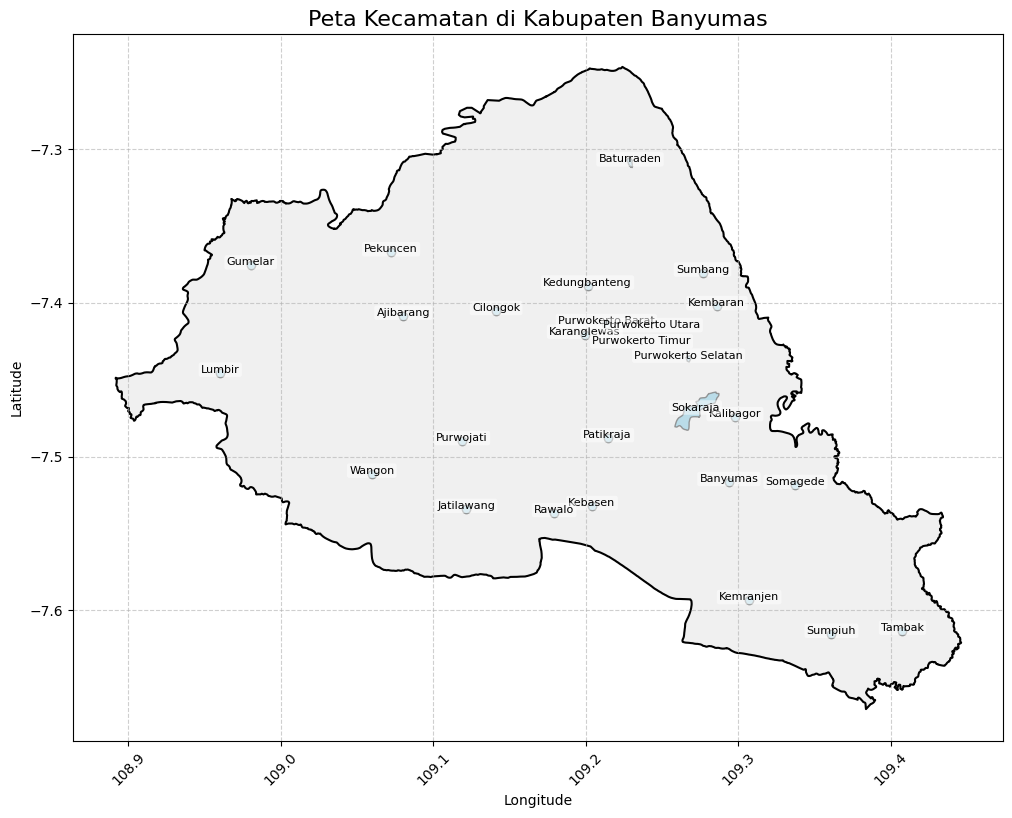

Peta berhasil ditampilkan.


In [23]:
# 1. Impor Pustaka (setiap modul di baris terpisah)
import osmnx as ox
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# 2. Daftar Lengkap 27 Kecamatan di Kabupaten Banyumas
#    (Daftar sebelumnya kurang 8 kecamatan)
list_kec_banyumas = [
    "Ajibarang, Banyumas, Central Java, Indonesia",
    "Banyumas, Banyumas, Central Java, Indonesia",
    "Baturraden, Banyumas, Central Java, Indonesia",
    "Cilongok, Banyumas, Central Java, Indonesia",
    "Gumelar, Banyumas, Central Java, Indonesia",
    "Jatilawang, Banyumas, Central Java, Indonesia",
    "Kalibagor, Banyumas, Central Java, Indonesia",
    "Karanglewas, Banyumas, Central Java, Indonesia",
    "Kebasen, Banyumas, Central Java, Indonesia",
    "Kedungbanteng, Banyumas, Central Java, Indonesia",
    "Kembaran, Banyumas, Central Java, Indonesia",
    "Kemranjen, Banyumas, Central Java, Indonesia",
    "Lumbir, Banyumas, Central Java, Indonesia",
    "Patikraja, Banyumas, Central Java, Indonesia",
    "Pekuncen, Banyumas, Central Java, Indonesia",
    "Purwojati, Banyumas, Central Java, Indonesia",
    "Purwokerto Barat, Banyumas, Central Java, Indonesia",
    "Purwokerto Selatan, Banyumas, Central Java, Indonesia",
    "Purwokerto Timur, Banyumas, Central Java, Indonesia",
    "Purwokerto Utara, Banyumas, Central Java, Indonesia",
    "Rawalo, Banyumas, Central Java, Indonesia",
    "Sokaraja, Banyumas, Central Java, Indonesia",
    "Somagede, Banyumas, Central Java, Indonesia",
    "Sumbang, Banyumas, Central Java, Indonesia",
    "Sumpiuh, Banyumas, Central Java, Indonesia",
    "Tambak, Banyumas, Central Java, Indonesia",
    "Wangon, Banyumas, Central Java, Indonesia"
]

# 3. Proses Geocode Semua Kecamatan dengan Penanganan Error
#    Logika Anda di sini sudah sangat baik, tidak perlu diubah.
geo_list = []
print("Memulai proses geocoding untuk 27 kecamatan...")
for kec in list_kec_banyumas:
    try:
        # Mencoba mengambil data poligon
        gdf = ox.geocode_to_gdf(kec)
        gdf["name"] = kec.split(",")[0]
        geo_list.append(gdf)
        print(f"✅ Berhasil mendapatkan poligon untuk: {kec.split(',')[0]}")
    except Exception as e:
        print(f"⚠️ Poligon tidak ditemukan untuk {kec.split(',')[0]}, mencoba mencari titik koordinat...")
        try:
            # Jika poligon gagal, ambil titik koordinatnya saja
            point = ox.geocode(kec)
            gdf_point = gpd.GeoDataFrame(
                {"name": [kec.split(",")[0]]},
                geometry=gpd.points_from_xy([point[1]], [point[0]]),
                crs="EPSG:4326"
            )
            geo_list.append(gdf_point)
            print(f"    -> Berhasil ditambahkan sebagai titik.")
        except Exception as e:
            print(f"    -> ❌ Gagal total untuk menemukan lokasi: {kec.split(',')[0]}")

# 4. Gabungkan Semua Hasil ke Satu GeoDataFrame
kecamatan_banyumas = gpd.GeoDataFrame(pd.concat(geo_list, ignore_index=True), crs="EPSG:4326")
print("\nProses geocoding selesai.")

# 5. Plot Peta
#    Logika plot Anda juga sudah benar.
print("Membuat plot peta...")
kabupaten = ox.geocode_to_gdf("Kabupaten Banyumas, Jawa Tengah, Indonesia")

fig, ax = plt.subplots(figsize=(12, 12))
kabupaten.plot(ax=ax, color="#f0f0f0", edgecolor="black", linewidth=1.5)

# Plot setiap kecamatan (bisa poligon atau titik)
kecamatan_banyumas.plot(ax=ax, color="lightblue", alpha=0.8, edgecolor="gray")

# Tambahkan label nama kecamatan di titik tengah (centroid)
for idx, row in kecamatan_banyumas.iterrows():
    # Pastikan geometri valid sebelum menghitung centroid
    if row.geometry and not row.geometry.is_empty:
        centroid = row.geometry.centroid
        ax.text(centroid.x, centroid.y, row["name"], fontsize=8, ha="center", color="black",
                bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', boxstyle='round,pad=0.2'))

ax.set_title("Peta Kecamatan di Kabupaten Banyumas", fontsize=16)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.tick_params(axis='x', rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
print("Peta berhasil ditampilkan.")

In [27]:
List_Kec_Banyumas = [
"Baturraden, Banyumas, Central Java, Indonesia",
"Purwokerto Selatan, Banyumas, Central Java, Indonesia",
"Purwokerto Timur, Banyumas, Central Java, Indonesia",
"Purwokerto Utara, Banyumas, Central Java, Indonesia",
"Sokaraja, Banyumas, Central Java, Indonesia",
]
sekolahan_banyumas = ox.features_from_place(
"Kabupaten Banyumas, Jawa Tengah, Indonesia",
tags={
"amenity": "school"
}
)
print("Jumlah total data penginapan ditemukan:", len(sekolahan_banyumas))
# Cek kolom yang tersedia
print("\nKolom yang tersedia di GeoDataFrame:")
print(sekolahan_banyumas.columns)
# Pilih kolom yang ada (agar tidak error)
sekolahan_tersedia = [col for col in ["name", "amenity"] if col in
sekolahan_banyumas.columns]
print("\nMenampilkan kolom:", sekolahan_tersedia)
# Tampilkan semua hasil (bukan hanya 5)
pd.set_option("display.max_rows", None) # tampilkan semua baris
pd.set_option("display.max_columns", None) # tampilkan semua kolom
# Tampilkan semua data sekolah
display(sekolahan_banyumas[sekolahan_tersedia])

Jumlah total data penginapan ditemukan: 173

Kolom yang tersedia di GeoDataFrame:
Index(['geometry', 'amenity', 'int_name', 'name', 'source', 'addr:street',
       'name:en', 'check_date', 'addr:city', 'addr:housenumber',
       'addr:postcode', 'grades', 'religion', 'building', 'operator:type',
       'school:type_idn', 'designation', 'layer', 'phone', 'website',
       'type:id', 'access:roof', 'addr:full', 'building:levels',
       'building:roof', 'building:structure', 'building:walls',
       'capacity:persons', 'description', 'type'],
      dtype='object')

Menampilkan kolom: ['name', 'amenity']


name amenity
element  id                                                           
node     1999787408                    SMA Negeri 2 Purwokerto  school
         1999787409                    SMA Negeri 3 Purwokerto  school
         1999787412                    SMA Bruderan Purwokerto  school
         1999787414                    SMA Negeri 5 Purwokerto  school
         1999787415                    SMA Negeri 1 Purwokerto  school
         1999787416                           MAN 2 Purwokerto  school
         1999787417                    SMK Negeri 2 Purwokerto  school
         1999787420                    SMK Negeri 1 Purwokerto  school
         1999787426                           MAN 1 Purwokerto  school
         2046027702                            SMP N 1 Gumelar  school
         2057035143                       Putra Harapan School  school
         2073124197                                        NaN  school
         2334376600                         SMP N 5 Purwokerto  school
         2387721965                             SDN Karang Rau  school
         4484352291                                        NaN  school
         6884198569       Institut Teknologi Telkom Purwokerto  school
         6884198570                      SMK Telkom Purwokerto  school
         6884198571                      SMP Telkom Purwokerto  school
         7707315312                    SMK Budi Utomo Sokaraja  school
         7708523891                SD Negeri 1 Sokaraja Tengah  school
         7708523897                      SMP Negeri 2 Sokaraja  school
         7708523900                  SMA Muhammadiyah Sokaraja  school
         7708523914                      SMP Negeri 1 Sokaraja  school
         8585328502                             Sekolah school  school
         9233017615                                SDN 1 Petir  school
         9233017616                           TK Pertiwi Petir  school
         9233041317                     SMP Negeri 3 Kalibagor  school
         9233041379                                SDN 2 Petir  school
         10175274172                          SD Negri Kober 1  school
         10962971592                           SMKN 2 Banyumas  school
         10962985762                           SMKN 1 Banyumas  school
         10962992064                                SD N Plana  school
         11151958390                   SD Negeri 1 Karangnanas  school
relation 2836248                                MAN 2 Banyumas  school
         2836728           Masuk SMP Muhammadiyah 1 Purwokerto  school
         3483109                            SDN 05 Purwanegara  school
         11931730                     SD Negeri 2 Pasirmuncang  school
way      178444424                             SMAN 1 Sokaraja  school
         190733803      SMA Islam Terpadu Al-Irsyad Purwokerto  school
         194224513                              SDN II Samudra  school
         194224812                             SDN VII Samudra  school
         195039927                          SD Negeri 4 Kranji  school
         195980137                           SMP N 1 Ajibarang  school
         196047226                     SMA Negeri 1 Purwokerto  school
         196047227                     SMA Negeri 2 Purwokerto  school
         196411108                     SMK Negeri 2 Purwokerto  school
         196411114                      SMA Veteran Purwokerto  school
         197025166                             SMP N 3 Gumelar  school
         197025170                              SDN Samudra VI  school
         197127175                    SD Negeri 1 Pasirmuncang  school
         197923054                                         NaN  school
         197923056                                         NaN  school
         199338227                     SMA Negeri 4 Purwokerto  school
         211566345                    SMP Kristen 1 Purwokerto  school
         211566380                      SMA Kristen Purwokerto  school
         21

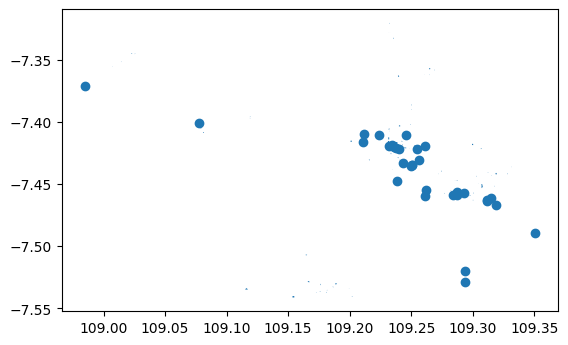

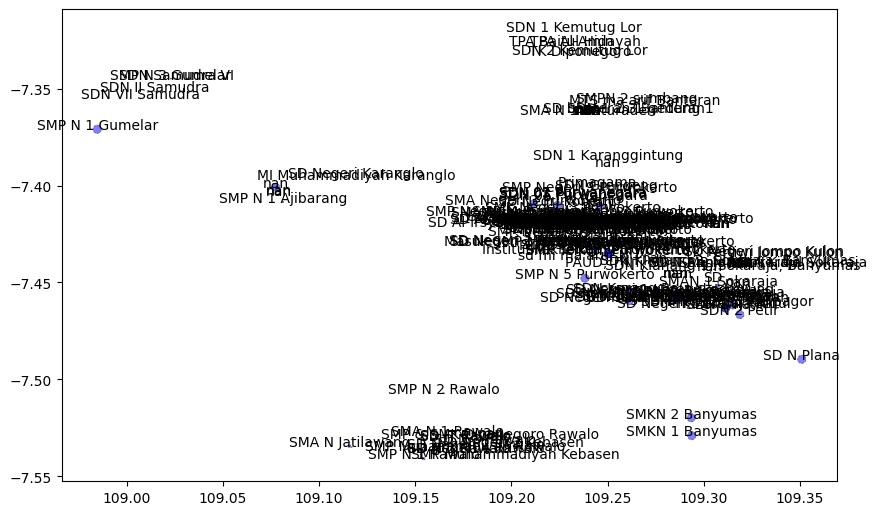

In [29]:
sekolahan_banyumas.plot()

fig, ax= plt.subplots(figsize=(10,10))
sekolahan_banyumas.plot(ax=ax, color="blue", alpha=0.5, linestyle='--', linewidth=0.5, edgecolor="black")

for idx, row in sekolahan_banyumas.iterrows():
    ax.annotate(text=row['name'], xy=row.geometry.centroid.coords[0], ha='center', fontsize=10, color="black")

plt.show()

In [33]:
place = "Purwokerto, Banyumas, Central Java, Indonesia"
tags = {"building": True}
building = ox.features_from_place(place, tags)
building.shape
building.head()

geometry  \
element id                                       
node    1448608332  POINT (109.23622 -7.42534)   
        1887657631  POINT (109.29846 -7.45788)   
        2006020429  POINT (109.24238 -7.42907)   
        2047440108  POINT (109.01757 -7.34923)   
        2817178267  POINT (109.28721 -7.45572)   

                                       addr:housename addr:housenumber  \
element id                                                               
node    1448608332                      Wisma Merdeka               17   
        1887657631                                NaN              NaN   
        2006020429  Kantor Kelurahan Purwokerto Kulon              NaN   
        2047440108                                NaN              NaN   
        2817178267                                NaN              NaN   

                       addr:street building  \
element id                                    
node    1448608332   Jalan Merdeka      yes   
        1887657631             NaN      yes   
        2006020429  Jalan Situmpur   public   
        2047440108             NaN   mosque   
        2817178267             NaN   office   

                                                 name addr:city  \
element id                                                        
node    1448608332                    Gedhe Institute       NaN   
        1887657631      Klenteng Hok Tek Bio Sokaraja  Sokaraja   
        2006020429    Purwokerto Kulon Community Hall       NaN   
        2047440108                      Masjid Bribis       NaN   
        2817178267  Kantor Kepala Desa Sokaraja Kulon       NaN   

                             amenity  religion  \
element id                                       
node    1448608332               NaN       NaN   
        1887657631  place_of_worship  buddhist   
        2006020429               NaN       NaN   
        2047440108  place_of_worship    muslim   
        2817178267               NaN       NaN   

                                          designation denomination  \
element id                                                           
node    1448608332                                NaN          NaN   
        1887657631                                NaN          NaN   
        2006020429  Kantor Kelurahan Purwokerto Kulon          NaN   
        2047440108                                NaN        sunni   
        2817178267                                NaN          NaN   

                   opening_hours addr:district addr:postcode addr:province  \
element id                                                                   
node    1448608332           NaN           NaN           NaN           NaN   
        1887657631           NaN           NaN           NaN           NaN   
        2006020429           NaN           NaN           NaN           NaN   
        2047440108          24/7           NaN           NaN           NaN   
        2817178267           NaN           NaN           NaN           NaN   

                   addr:subdistrict air_conditioning branch email name:en  \
element id                                                                  
node    1448608332              NaN              NaN    NaN   NaN     NaN   
        1887657631              NaN              NaN    NaN   NaN     NaN   
        2006020429              NaN              NaN    NaN   NaN     NaN   
        2047440108              NaN              NaN    NaN   NaN     NaN   
        2817178267              NaN              NaN    NaN   NaN     NaN   

                   office official_name operator:type website wikidata  \
element id                                                               
node    1448608332    NaN           NaN           NaN     NaN      NaN   
        1887657631    NaN           NaN           NaN     NaN      NaN   
        2006020429    NaN           NaN           NaN     NaN      NaN   
        2047440108    NaN           NaN           NaN     NaN      Na

⬛  Banyumas, Central Java, Indonesia — 481578 bangunan diambil


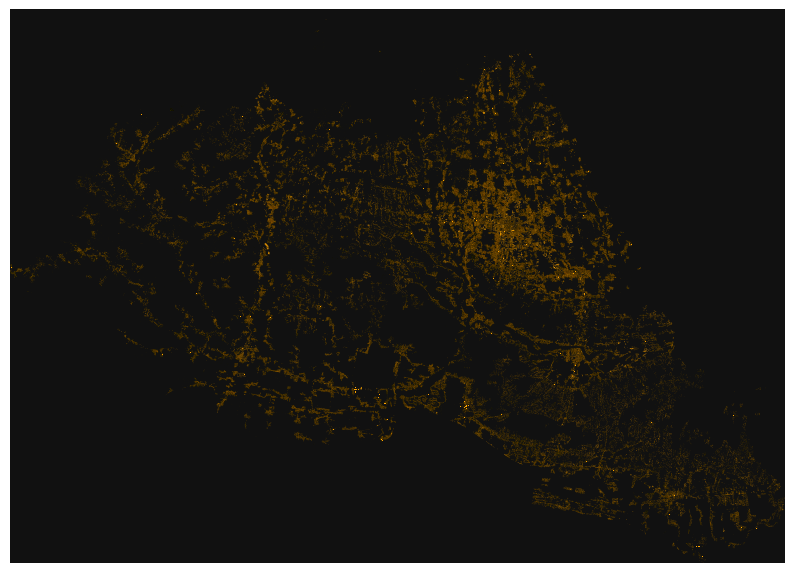

In [37]:
import osmnx as ox import geopandas as gpd import pandas as pd
import matplotlib.pyplot as plt
# Daftar kecamatan
places = [
"Banyumas, Central Java, Indonesia"
]

# Ambil semua bangunan dari tiap kecamatan buildings_list = []
for place in places: try:
b = ox.features_from_place(place, {"building": True}) buildings_list.append(b)
print(f"⬛  {place} — {len(b)} bangunan diambil") except Exception as e:
print(f".ı  Gagal mengambil data dari {place}: {e}")
# Gabungkan semuanya jadi satu GeoDataFrame
buildings = gpd.GeoDataFrame(pd.concat(buildings_list, ignore_index=True)) buildings = buildings.set_crs(epsg=4326)

# Plot seperti denah
fig, ax = ox.plot_footprints(buildings, figsize=(10, 10))


In [6]:
place = "Kabupaten Banyumas, Jawa Tengah, Indonesia" tag_building = {"tourism":"sekolahan"}
building = ox.features_from_place(place, tag_building) building.shape
building.head()


geometry amenity  \
element id                                               
node    1999787408  POINT (109.23586 -7.41999)  school   
        1999787409  POINT (109.21155 -7.40959)  school   
        1999787412  POINT (109.23215 -7.41934)  school   
        1999787414  POINT (109.23446 -7.41879)  school   
        1999787415  POINT (109.23745 -7.42092)  school   

                                          int_name                     name  \
element id                                                                    
node    1999787408  Purwokerto State High School 2  SMA Negeri 2 Purwokerto   
        1999787409                             NaN  SMA Negeri 3 Purwokerto   
        1999787412                             NaN  SMA Bruderan Purwokerto   
        1999787414                             NaN  SMA Negeri 5 Purwokerto   
        1999787415  Purwokerto State High School 1  SMA Negeri 1 Purwokerto   

                                         source                   addr:street  \
element id                                                                      
node    1999787408  www.sma2-purwokerto.sch.id/                           NaN   
        1999787409                          NaN                           NaN   
        1999787412                          NaN                           NaN   
        1999787414                          NaN                           NaN   
        1999787415   www.sma1purwokerto.sch.id/  Jalan Jenderal Gatot Subroto   

                   name:en check_date addr:city addr:housenumber  ... type:id  \
element id                                                        ...           
node    1999787408     NaN        NaN       NaN              NaN  ...     NaN   
        1999787409     NaN        NaN       NaN              NaN  ...     NaN   
        1999787412     NaN        NaN       NaN              NaN  ...     NaN   
        1999787414     NaN        NaN       NaN              NaN  ...     NaN   
        1999787415     NaN        NaN       NaN              NaN  ...     NaN   

                   access:roof addr:full building:levels building:roof  \
element id                                                               
node    1999787408         NaN       NaN             NaN           NaN   
        1999787409         NaN       NaN             NaN           NaN   
        1999787412         NaN       NaN             NaN           NaN   
        1999787414         NaN       NaN             NaN           NaN   
        1999787415         NaN       NaN             NaN           NaN   

                   building:structure building:walls capacity:persons  \
element id                                                              
node    1999787408                NaN            NaN              NaN   
        1999787409                NaN            NaN              NaN   
        1999787412                NaN            NaN              NaN   
        1999787414                NaN            NaN              NaN   
        1999787415                NaN            NaN              NaN   

                   description type  
element id                           
node    1999787408         NaN  NaN  
        1999787409         NaN  NaN  
        1999787412         NaN  NaN  
        1999787414         NaN  NaN  
        1999787415         NaN  NaN  

[5 rows x 30 columns]

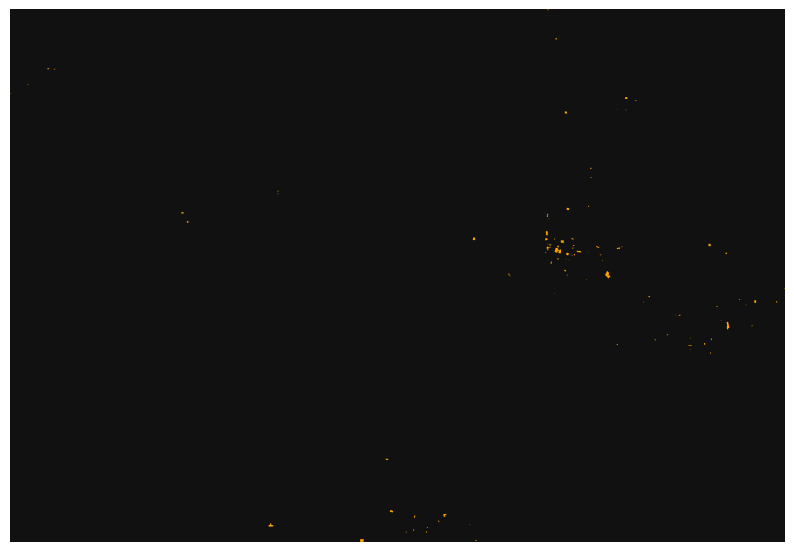

In [7]:
fig, ax = ox.plot_footprints(building, figsize=(10,10))

In [9]:
import osmnx as ox
# Batas koordinat wilayah Purwokerto dan sekitarnya
north, south, east, west = -7.3650, -7.4800, 109.3000, 109.1900

# Ambil semua bangunan di dalam bounding box buildings_bbox =
ox.features.features_from_bbox((west,south,east,north),tags={"building": True}) print(buildings_bbox.shape)
buildings_bbox.head()


(159552, 88)


geometry  \
element id                                       
node    1448608332  POINT (109.23622 -7.42534)   
        1887657631  POINT (109.29846 -7.45788)   
        2006020429  POINT (109.24238 -7.42907)   
        2817178267  POINT (109.28721 -7.45572)   
        2817186660  POINT (109.27915 -7.45906)   

                                       addr:housename addr:housenumber  \
element id                                                               
node    1448608332                      Wisma Merdeka               17   
        1887657631                                NaN              NaN   
        2006020429  Kantor Kelurahan Purwokerto Kulon              NaN   
        2817178267                                NaN              NaN   
        2817186660                                NaN              NaN   

                       addr:street building  \
element id                                    
node    1448608332   Jalan Merdeka      yes   
        1887657631             NaN      yes   
        2006020429  Jalan Situmpur   public   
        2817178267             NaN   office   
        2817186660             NaN   office   

                                                 name addr:city  \
element id                                                        
node    1448608332                    Gedhe Institute       NaN   
        1887657631      Klenteng Hok Tek Bio Sokaraja  Sokaraja   
        2006020429    Purwokerto Kulon Community Hall       NaN   
        2817178267  Kantor Kepala Desa Sokaraja Kulon       NaN   
        2817186660                 Kantor Kepala Desa       NaN   

                             amenity  religion  \
element id                                       
node    1448608332               NaN       NaN   
        1887657631  place_of_worship  buddhist   
        2006020429               NaN       NaN   
        2817178267               NaN       NaN   
        2817186660               NaN       NaN   

                                          designation  ... stamps addr:unit  \
element id                                             ...                    
node    1448608332                                NaN  ...    NaN       NaN   
        1887657631                                NaN  ...    NaN       NaN   
        2006020429  Kantor Kelurahan Purwokerto Kulon  ...    NaN       NaN   
        2817178267                                NaN  ...    NaN       NaN   
        2817186660                                NaN  ...    NaN       NaN   

                   height healthcare:speciality mobile recycling_type  \
element id                                                              
node    1448608332    NaN                   NaN    NaN            NaN   
        1887657631    NaN                   NaN    NaN            NaN   
        2006020429    NaN                   NaN    NaN            NaN   
        2817178267    NaN                   NaN    NaN            NaN   
        2817186660    NaN                   NaN    NaN            NaN   

                   internet_access:fee disused:railway house type  
element id                                                         
node    1448608332                 NaN             NaN   NaN  NaN  
        1887657631                 NaN             NaN   NaN  NaN  
        2006020429                 NaN             NaN   NaN  NaN  
        2817178267                 NaN             NaN   NaN  NaN  
        2817186660                 NaN             NaN   NaN  NaN  

[5 rows x 88 columns]

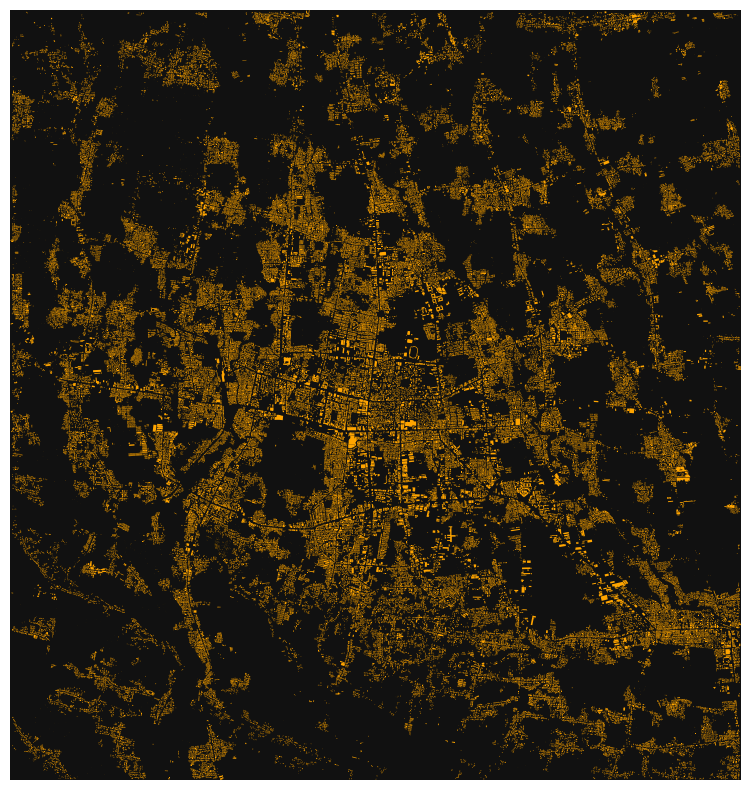

In [10]:
fig, ax = ox.plot_footprints(buildings_bbox, figsize=(10,10))

In [13]:
!pip install contextily


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 48.4 MB/s eta 0:00:00


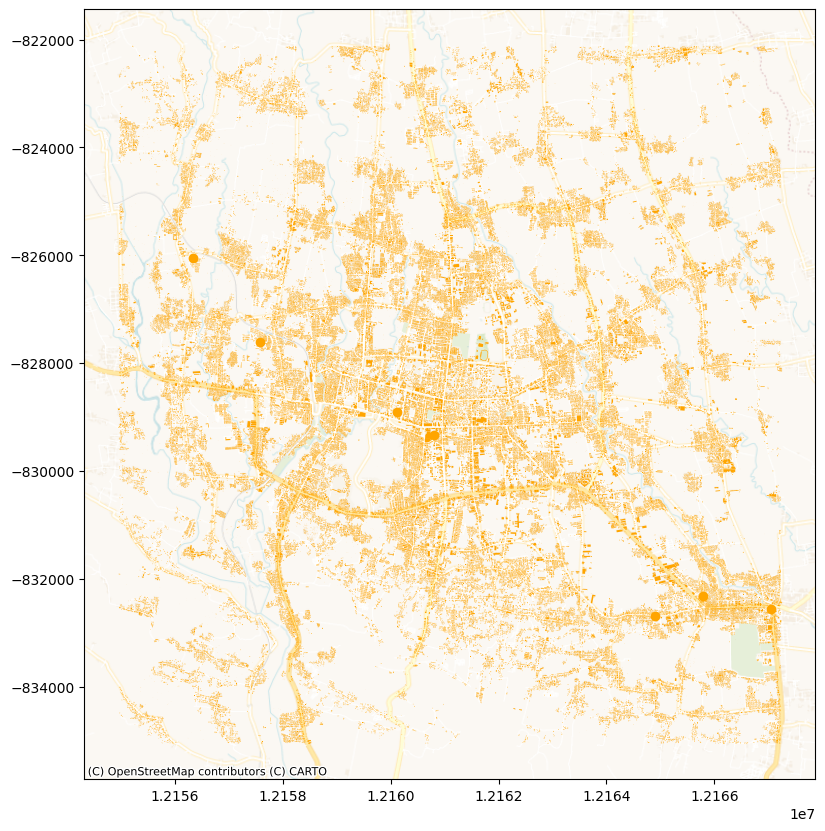

In [15]:
f, ax = plt.subplots(1, figsize=(10, 10)) buildings_bbox.plot(ax=ax, color='orange') cx.add_basemap(
ax, crs="EPSG:3857",
source=cx.providers.CartoDB.VoyagerNoLabels
)


⬛  Jumlah sekolah ditemukan: 10

- SMA Negeri 2 Purwokerto: (-7.4199902, 109.2358554)
- SMA Negeri 3 Purwokerto: (-7.4095853, 109.2115536)
- SMA Bruderan Purwokerto: (-7.4193414, 109.232153)
- SMA Negeri 5 Purwokerto: (-7.4187882, 109.2344597)
- SMA Negeri 1 Purwokerto: (-7.420916, 109.237453)
- MAN 2 Purwokerto: (-7.4302994, 109.2565938)
- SMK Negeri 2 Purwokerto: (-7.4219054, 109.2404571)
- SMK Negeri 1 Purwokerto: (-7.4214266, 109.2543831)
- MAN 1 Purwokerto: (-7.4194584, 109.2614749)
- SMP N 1 Gumelar: (-7.3709821, 108.9845731)

=== Tabel Jarak Antar Sekolah (meter) ===


,SMA Negeri 2 Purwokerto,SMA Negeri 3 Purwokerto,SMA Bruderan Purwokerto,SMA Negeri 5 Purwokerto,SMA Negeri 1 Purwokerto,MAN 2 Purwokerto,SMK Negeri 2 Purwokerto,SMK Negeri 1 Purwokerto,MAN 1 Purwokerto,SMP N 1 Gumelar
SMA Negeri 2 Purwokerto,0,2919.16,414.97,203.5,203.93,2557.55,550.38,2051.49,2828.84,28265.96
SMA Negeri 3 Purwokerto,2919.16,0,2517.05,2725.85,3121.7,5474.5,3469.52,4906.15,5618.18,25419.91
SMA Bruderan Purwokerto,414.97,2517.05,0,261.89,610.45,2957.75,959.57,2464.87,3236.98,27851.06
SMA Negeri 5 Purwokerto,203.5,2725.85,261.89,0,405.67,2755.19,746.45,2218.68,2983.23,28089.46
SMA Negeri 1 Purwokerto,203.93,3121.7,610.45,405.67,0,2354.07,349.22,1869.82,2656.75,28458.74
MAN 2 Purwokerto,2557.55,5474.5,2957.75,2755.19,2354.07,0,2008.74,1011.16,1314.46,30738.78
SMK Negeri 2 Purwokerto,550.38,3469.52,959.57,746.45,349.22,2008.74,0,1538.25,2335.95,28805.32
SMK Negeri 1 Purwokerto,2051.49,4906.15,2464.87,2218.68,1869.82,1011.16,1538.25,0,812.58,30304.79
MAN 1 Purwokerto,2828.84,5618.18,3236.98,2983.23,2656.75,1314.46,2335.95,812.58,0,31036.4
SMP N 1 Gumelar,28265.96,25419.91,27851.06,28089.46,28458.74,30738.78,28805.32,30304.79,31036.4,0


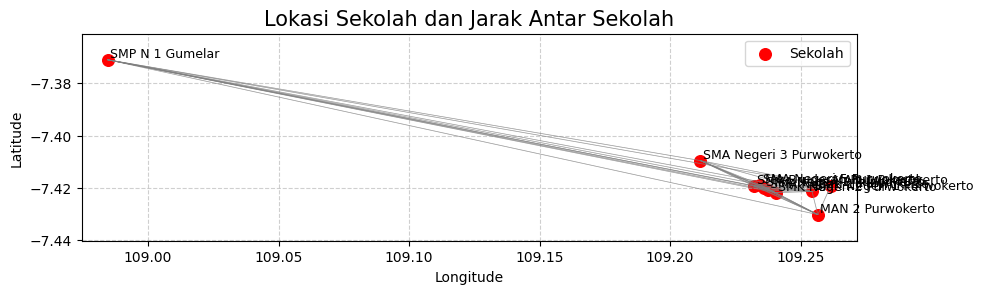

In [18]:
!pip install osmnx contextily geopy pandas matplotlib

import osmnx as ox
import contextily as cx
import matplotlib.pyplot as plt
import pandas as pd
from geopy.distance import geodesic

# Ambil data sekolah dari wilayah Banyumas
sekolah_gdf = ox.features_from_place(
"Kabupaten Banyumas, Jawa Tengah, Indonesia", tags={"amenity": "school"}
)
# Bersihkan data dan ambil yang punya koordinat valid
sekolah_gdf = sekolah_gdf[sekolah_gdf.geometry.notnull()].copy()

# Ambil maksimal 10 sekolah agar tidak terlalu berat
sekolah_gdf = sekolah_gdf.head(10)
# Ambil nama dan koordinat
school_names = sekolah_gdf["name"].fillna("Sekolah Tanpa Nama").tolist()
school_coords = [(geom.centroid.y, geom.centroid.x) for geom in sekolah_gdf.geometry]
# Simpan ke dict
schools = dict(zip(school_names, school_coords))

print(f"⬛  Jumlah sekolah ditemukan: {len(schools)}\n")
for k, v in schools.items():
    print(f"- {k}: {v}")

# Buat tabel jarak antarsekolah ===
def distance(a, b):
    return geodesic(a, b).meters

names = list(schools.keys())
distance_matrix = pd.DataFrame(index=names, columns=names)

for i in names:
    for j in names:
        if i == j:
            distance_matrix.loc[i, j] = 0
        else:
            distance_matrix.loc[i, j] = round(distance(schools[i], schools[j]), 2)

print("\n=== Tabel Jarak Antar Sekolah (meter) ===")
display(distance_matrix)

# === Plot peta dengan background ===
fig, ax = plt.subplots(figsize=(10, 10))

# Plot titik sekolah
for name, (lat, lon) in schools.items():
    ax.scatter(lon, lat, color="red", s=70, label="Sekolah" if name == names[0] else "")
    ax.text(lon + 0.001, lat + 0.001, name, fontsize=9, color="black")

# Garis antar semua sekolah
for i in names:
    for j in names:
        if i != j:
            a = schools[i]
            b = schools[j]
            ax.plot([a[1], b[1]], [a[0], b[0]], color='gray', linestyle='-', linewidth=0.5, alpha=0.5)


# Reproject the axis to EPSG:3857 for contextily
ax.set_aspect('equal') # Maintain aspect ratio
ax.autoscale(enable=True) # Autoscale the axis limits
ax.set_xlim([min(lon for _, (lat, lon) in schools.items()) - 0.01, max(lon for _, (lat, lon) in schools.items()) + 0.01])
ax.set_ylim([min(lat for _, (lat, lon) in schools.items()) - 0.01, max(lat for _, (lat, lon) in schools.items()) + 0.01])

# Add basemap - requires axis to be in EPSG:3857
# Reproject the axis to 3857 before adding the basemap
# Note: Plotting lat/lon directly on 3857 axis will distort,
# but contextily needs the axis in 3857.
# A better approach for accurate plotting and basemap is to
# reproject the points themselves, but for simplicity here,
# we adjust the axis CRS for contextily.
ax.set_title("Lokasi Sekolah dan Jarak Antar Sekolah", fontsize=15)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()